# Stage 2 — Analyze CV and Select Objectives

**Fast execution only.  Requires NB1 to have been run first.**

Loads the raw SWMM cache, runs 23-fold LOOCV for each candidate objective set,
and identifies the set that best generalizes to unseen storms.

Fails gracefully with a clear message if the cache is missing or stale.

| Output | Path |
|--------|------|
| LOOCV validation summary | `outputs/results/loocv/loocv_validation_summary.csv` |
| Per-fold checkpoints | `outputs/results/loocv/fold_*.pkl` |
| Full-fold aggregates | `outputs/results/loocv/all_folds_*.pkl` |
| Full-set objectives cache | `outputs/results/loocv/loocv_full_objectives_cache.pkl` |
| Pareto grid plot | `outputs/metrics/loocv_pareto_grid.png` |
| Objective comparison bar | `outputs/metrics/loocv_objective_comparison.png` |
| Validation scatter | `outputs/metrics/loocv_validation_scatter.png` |

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

PROJECT_ROOT      = Path('.')
RESULTS_DIR       = PROJECT_ROOT / 'outputs' / 'results' / 'loocv'
METRICS_DIR       = PROJECT_ROOT / 'outputs' / 'metrics'
CALIBRATION_CACHE = RESULTS_DIR / 'loocv_calibration_cache.pkl'
LOOCV_SUMMARY_CSV = RESULTS_DIR / 'loocv_validation_summary.csv'

for _d in [RESULTS_DIR, METRICS_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Candidate objective sets to compare.
# Add new entries here — no SWMM re-runs required.
CANDIDATE_OBJECTIVE_SETS = {
    'legacy_winner':         ['peak_1-kge', 'volume_1-kge', 'peak_rmsd',  'peak_bias'],
    'peak_kge_volume_kge':   ['peak_1-kge', 'volume_1-kge'],
    'peak_rmsd_volume_rmsd': ['peak_rmsd',  'volume_rmsd'],
    'all_peak':              ['peak_1-kge', 'peak_rmsd',    'peak_bias',  'peak_mad'],
}

# ── Manual winner selection ───────────────────────────────────────────────────
# After reviewing the LOOCV summary table, set this to the name of the set
# you want to use for Stage 3.  Must match a key in CANDIDATE_OBJECTIVE_SETS.
# Leave as None to auto-select the top-ranked set by mean_peak_rel_err.
WINNING_SET_OVERRIDE = 'legacy_winner'

print('NB2  -  Analyze CV and Select Objectives')
print(f'  Cache       : {CALIBRATION_CACHE}')
print(f'  Summary out : {LOOCV_SUMMARY_CSV}')
print(f'  Candidates  : {list(CANDIDATE_OBJECTIVE_SETS)}')
if WINNING_SET_OVERRIDE is not None:
    print(f'  [MANUAL]    : winner overridden to {WINNING_SET_OVERRIDE!r}')

NB2  -  Analyze CV and Select Objectives
  Cache       : outputs\results\loocv\loocv_calibration_cache.pkl
  Summary out : outputs\results\loocv\loocv_validation_summary.csv
  Candidates  : ['legacy_winner', 'peak_kge_volume_kge', 'peak_rmsd_volume_rmsd', 'all_peak']
  [MANUAL]    : winner overridden to 'legacy_winner'


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pickle, logging
import numpy as np
import pandas as pd

from urban_runoff.config import PARAMETER_GRID, FILTER_BOUNDS
from urban_runoff.calibration.cross_validation import (
    build_factor_combinations,
    validate_calibration_cache,
    merge_calibration_results,
    apply_filter_bounds_to_list,
)
from urban_runoff.calibration.objectives import (
    compute_objective_functions, build_objectives_dataframe,
)
from urban_runoff.calibration.loocv import run_full_loocv
from urban_runoff.optimization.pareto   import find_pareto_front, normalize_columns
from urban_runoff.optimization.selection import closest_row_to_origin

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('nb2_analyze_cv')

In [3]:
# ── Load cache — fail gracefully if missing or stale ─────────────────────────
factor_combinations = build_factor_combinations()

if not CALIBRATION_CACHE.exists():
    raise FileNotFoundError(
        f'Calibration cache not found:\n  {CALIBRATION_CACHE}\n\n'
        'Run 01_Generate_LOOCV_Cache.ipynb first.'
    )

with open(CALIBRATION_CACHE, 'rb') as _f:
    _cached = pickle.load(_f)

if not validate_calibration_cache(_cached, factor_combinations):
    raise RuntimeError(
        'PARAMETER_GRID in config.py has changed since the cache was built.\n'
        'The cache is stale.  Run 01_Generate_LOOCV_Cache.ipynb to regenerate it.'
    )

cali_results_df_l = _cached['cali_results_df_l']
hydrograph_df_l   = _cached['hydrograph_df_l']
obs_hydrograph_df = _cached['obs_hydrograph_df']
logger.info('Cache loaded: %d events, %d combos each.',
            len(cali_results_df_l), len(cali_results_df_l[0]))

12:58:39 INFO     nb2_analyze_cv: Cache loaded: 23 events, 1323 combos each.


In [4]:
# ── Physical bounds filter ────────────────────────────────────────────────────
# Edit FILTER_BOUNDS in config.py to restrict the parameter search space.
# e.g.  "imperviousness": (1.0, 1.5)  to exclude sub-baseline IMP factors.
# Default (all None) keeps the full grid.  No SWMM re-runs needed.

_n_before = len(cali_results_df_l[0])
cali_results_df_l = apply_filter_bounds_to_list(cali_results_df_l, FILTER_BOUNDS)
hydrograph_df_l   = apply_filter_bounds_to_list(hydrograph_df_l,   FILTER_BOUNDS)
_n_after  = len(cali_results_df_l[0])

active = {k: v for k, v in FILTER_BOUNDS.items() if v is not None}
print(f'Bounds filter: {_n_before} -> {_n_after} rows '
      f'({_n_before - _n_after} dropped)' if _n_before != _n_after
      else f'Bounds filter: {_n_before} rows (no filter active)')
if active:
    print(f'Active bounds: {active}')

12:58:39 INFO     urban_runoff.calibration.cross_validation: apply_filter_bounds: kept 648 / 1323 rows after bounds filtering
12:58:39 INFO     urban_runoff.calibration.cross_validation: apply_filter_bounds: kept 648 / 1323 rows after bounds filtering


Bounds filter: 1323 -> 648 rows (675 dropped)
Active bounds: {'imperviousness': (1.0, 1.5), 'storage': (0.1, 7.0)}


In [5]:
# ── Full LOOCV across all candidate objective sets ────────────────────────────
# Per-fold checkpoints in RESULTS_DIR allow resuming interrupted runs.
# Adding new sets to CANDIDATE_OBJECTIVE_SETS requires zero new SWMM runs.

loocv_summary = run_full_loocv(
    cali_results_df_l        = cali_results_df_l,
    hydrograph_df_l          = hydrograph_df_l,
    obs_hydrograph_df        = obs_hydrograph_df,
    candidate_objective_sets = CANDIDATE_OBJECTIVE_SETS,
    results_dir              = RESULTS_DIR,
)

print('\n=== LOOCV Validation Summary (sorted by mean peak relative error) ===')
print(loocv_summary[
    ['objectives', 'mean_peak_rel_err', 'std_peak_rel_err',
     'mean_vol_rel_err', 'std_vol_rel_err', 'n_folds']
].to_string())

12:58:39 INFO     urban_runoff.calibration.loocv: LOOCV: objective set 'legacy_winner' (4 objectives, 23 folds)
12:58:41 INFO     urban_runoff.optimization.pareto: find_pareto_front: 9/648 solutions are Pareto-optimal (1.4%)
12:58:41 INFO     urban_runoff.calibration.loocv:   Fold  1/23 (2012_01_13): peak_rel_err=0.103, vol_rel_err=0.024
12:58:43 INFO     urban_runoff.optimization.pareto: find_pareto_front: 14/648 solutions are Pareto-optimal (2.2%)
12:58:43 INFO     urban_runoff.calibration.loocv:   Fold  2/23 (2013_01_06): peak_rel_err=0.348, vol_rel_err=0.312
12:58:45 INFO     urban_runoff.optimization.pareto: find_pareto_front: 8/648 solutions are Pareto-optimal (1.2%)
12:58:45 INFO     urban_runoff.calibration.loocv:   Fold  3/23 (2014_12_14): peak_rel_err=0.743, vol_rel_err=0.556
12:58:47 INFO     urban_runoff.optimization.pareto: find_pareto_front: 9/648 solutions are Pareto-optimal (1.4%)
12:58:47 INFO     urban_runoff.calibration.loocv:   Fold  4/23 (2015_10_07): peak_rel_err=


=== LOOCV Validation Summary (sorted by mean peak relative error) ===
                                                           objectives  mean_peak_rel_err  std_peak_rel_err  mean_vol_rel_err  std_vol_rel_err  n_folds
obj_set_name                                                                                                                                          
peak_rmsd_volume_rmsd                          peak_rmsd, volume_rmsd           0.277043          0.238292          0.395994         0.406921       23
peak_kge_volume_kge                          peak_1-kge, volume_1-kge           0.282457          0.235608          0.400430         0.405608       23
legacy_winner          peak_1-kge, volume_1-kge, peak_rmsd, peak_bias           0.283405          0.259486          0.438518         0.465671       23
all_peak                   peak_1-kge, peak_rmsd, peak_bias, peak_mad           0.290595          0.263437          0.446169         0.464978       23


In [6]:
# ── Select winner and save CSV ────────────────────────────────────────────────
# To override the auto-selection, set WINNING_SET_OVERRIDE in the config cell
# and re-run from there.  The chosen set is placed first in the saved CSV so
# that NB3 (which reads index[0]) automatically picks it up.

if WINNING_SET_OVERRIDE is not None:
    if WINNING_SET_OVERRIDE not in loocv_summary.index:
        raise ValueError(
            f'WINNING_SET_OVERRIDE={WINNING_SET_OVERRIDE!r} is not a valid set name.\n'
            f'Available sets: {list(loocv_summary.index)}'
        )
    winning_set_name = WINNING_SET_OVERRIDE
    _selection_mode  = '[MANUAL OVERRIDE]'
else:
    winning_set_name = loocv_summary.index[0]
    _selection_mode  = '[AUTO-SELECTED]  '

winning_objs = CANDIDATE_OBJECTIVE_SETS[winning_set_name]

# Reorder so the selected set is always at index[0] — NB3 reads index[0].
_ordered = [winning_set_name] + [s for s in loocv_summary.index if s != winning_set_name]
loocv_summary = loocv_summary.loc[_ordered]
loocv_summary.to_csv(LOOCV_SUMMARY_CSV)

print(f'{_selection_mode} Winning set  : {winning_set_name!r}')
print(f'  Objectives   : {winning_objs}')
print(f'  Mean peak err: {loocv_summary.loc[winning_set_name, "mean_peak_rel_err"]:.4f}')
print(f'  Mean vol  err: {loocv_summary.loc[winning_set_name, "mean_vol_rel_err"]:.4f}')
print(f'\nSaved summary -> {LOOCV_SUMMARY_CSV}')
print('Next: 03_Final_Calibration.ipynb')

[MANUAL OVERRIDE] Winning set  : 'legacy_winner'
  Objectives   : ['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias']
  Mean peak err: 0.2834
  Mean vol  err: 0.4385

Saved summary -> outputs\results\loocv\loocv_validation_summary.csv
Next: 03_Final_Calibration.ipynb


## Visualization

All plots read from the LOOCV cache — no SWMM re-runs.

In [7]:
# ── Visualization setup ──────────────────────────────────────────────────────
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
import matplotlib.pyplot as plt

from urban_runoff.visualization.pareto_plots import plot_pareto_grid
from urban_runoff.visualization.scatter import (
    plot_loocv_summary_bar, plot_loocv_validation_scatter,
)

_full_obj_cache = RESULTS_DIR / 'loocv_full_objectives_cache.pkl'

if _full_obj_cache.exists():
    logger.info('Loading full-set objectives from cache.')
    with open(_full_obj_cache, 'rb') as _f:
        _oc = pickle.load(_f)
    _storm_obj_df  = _oc['storm_obj_df']
    _peak_obj_df   = _oc['peak_obj_df']
    _volume_obj_df = _oc['volume_obj_df']
else:
    logger.info('Computing objectives on all events (one-time) ...')
    _cali_merged  = merge_calibration_results(cali_results_df_l)
    _hydro_merged = merge_calibration_results(hydrograph_df_l)
    _storm_obj_df, _peak_obj_df, _volume_obj_df = compute_objective_functions(
        obs_hydrograph_df, _cali_merged, _hydro_merged,
    )
    with open(_full_obj_cache, 'wb') as _f:
        pickle.dump({
            'storm_obj_df':  _storm_obj_df,
            'peak_obj_df':   _peak_obj_df,
            'volume_obj_df': _volume_obj_df,
        }, _f)
    logger.info('Cached to %s', _full_obj_cache)

_objectives_flat = build_objectives_dataframe(
    _storm_obj_df, _peak_obj_df, _volume_obj_df,
    objective_names=winning_objs,
)
_obj_norm    = normalize_columns(_objectives_flat.abs())
_pareto_df   = find_pareto_front(_objectives_flat, normalize=True)
_pareto_norm = _obj_norm.loc[_pareto_df.index]
_optimum_row = closest_row_to_origin(_pareto_df)
_opt_norm    = _obj_norm.loc[_optimum_row.name]

print(f'Objective combinations : {len(_obj_norm)}')
print(f'Pareto front size      : {len(_pareto_df)} ({100*len(_pareto_df)/len(_obj_norm):.1f}%)')

13:01:47 INFO     nb2_analyze_cv: Computing objectives on all events (one-time) ...
13:01:49 INFO     nb2_analyze_cv: Cached to outputs\results\loocv\loocv_full_objectives_cache.pkl
13:01:49 INFO     urban_runoff.optimization.pareto: find_pareto_front: 12/648 solutions are Pareto-optimal (1.9%)


Objective combinations : 648
Pareto front size      : 12 (1.9%)


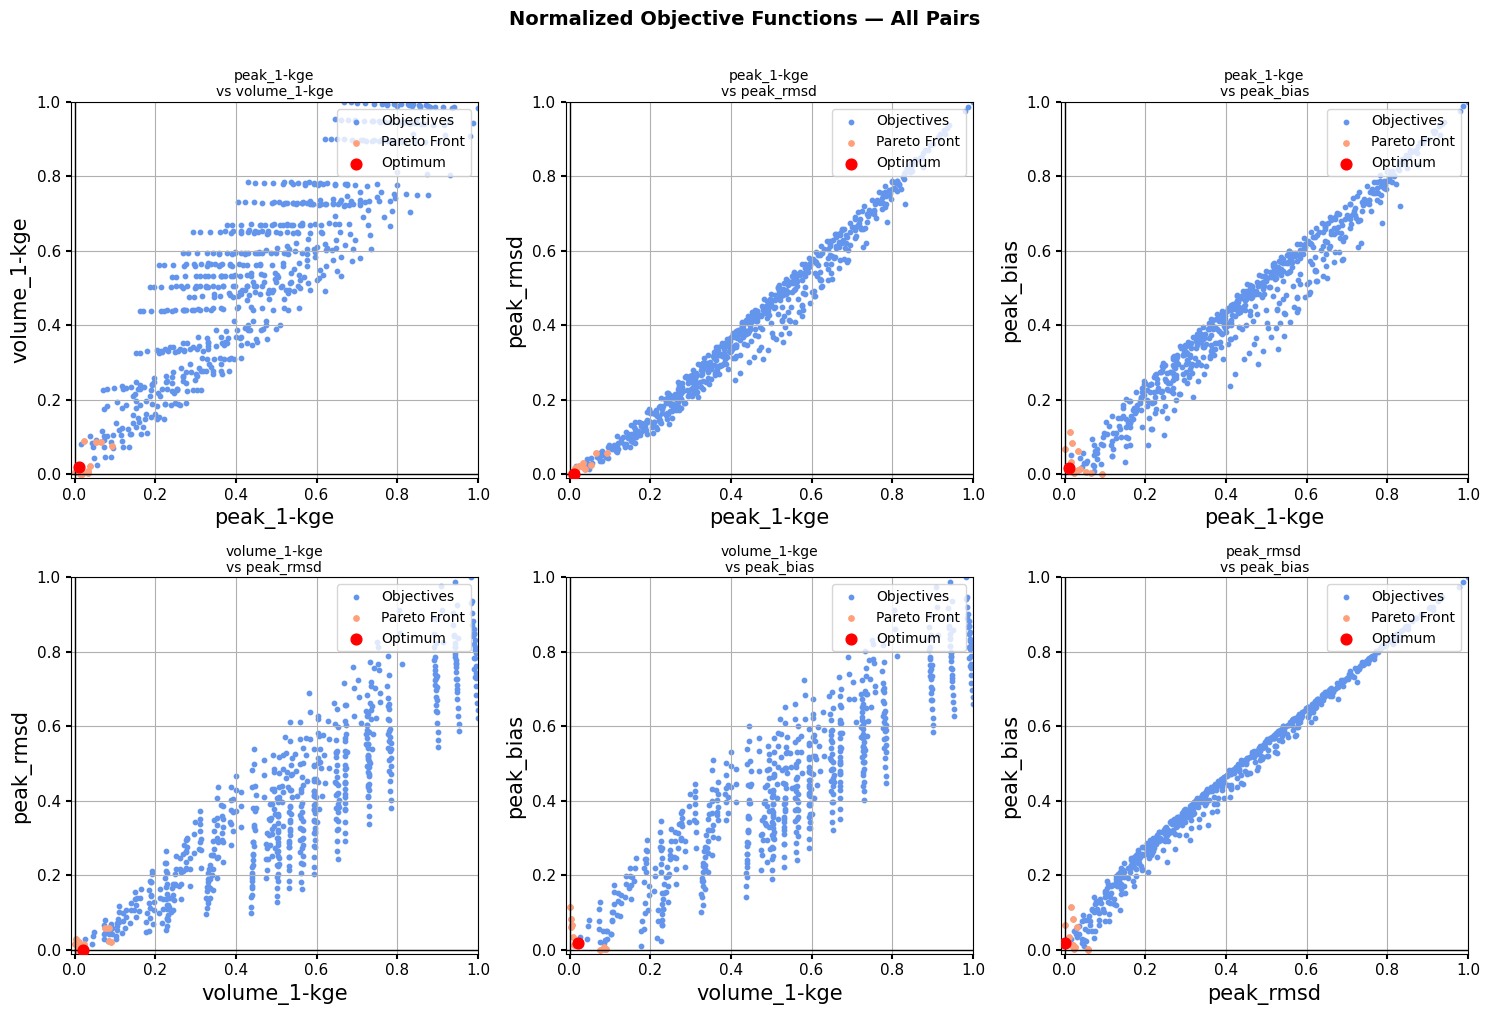

Saved -> outputs\metrics\loocv_pareto_grid.png


In [8]:
# ── Plot 1: Pareto front — all pairs (winning set) ───────────────────────────
fig1 = plot_pareto_grid(
    objectives_df   = _obj_norm,
    pareto_df       = _pareto_norm,
    optimum_row     = _opt_norm,
    objective_names = winning_objs,
    save_path       = str(METRICS_DIR / 'loocv_pareto_grid.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "loocv_pareto_grid.png"}')

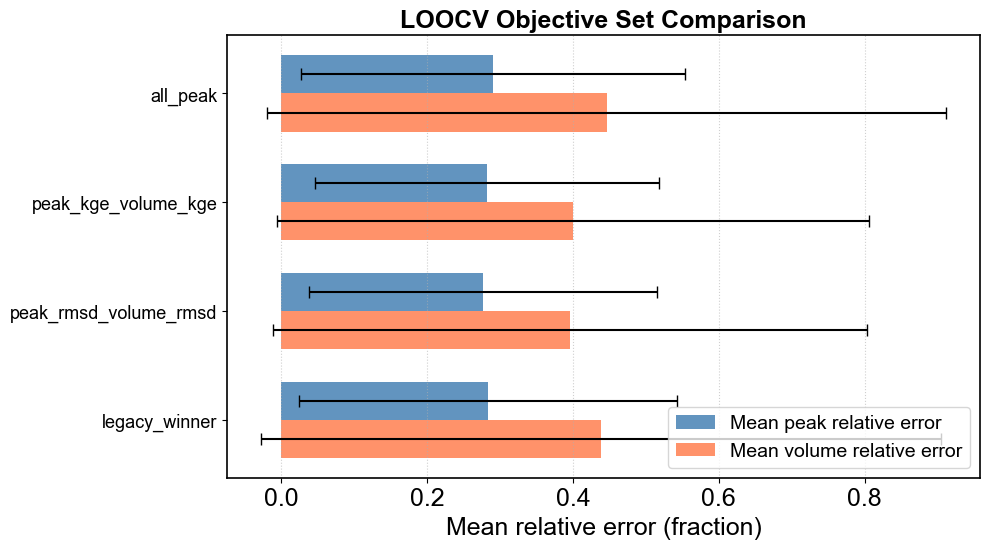

Saved -> outputs\metrics\loocv_objective_comparison.png


In [9]:
# ── Plot 2: Objective set comparison bar chart ───────────────────────────────
fig2 = plot_loocv_summary_bar(
    loocv_summary,
    save_path = str(METRICS_DIR / 'loocv_objective_comparison.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "loocv_objective_comparison.png"}')

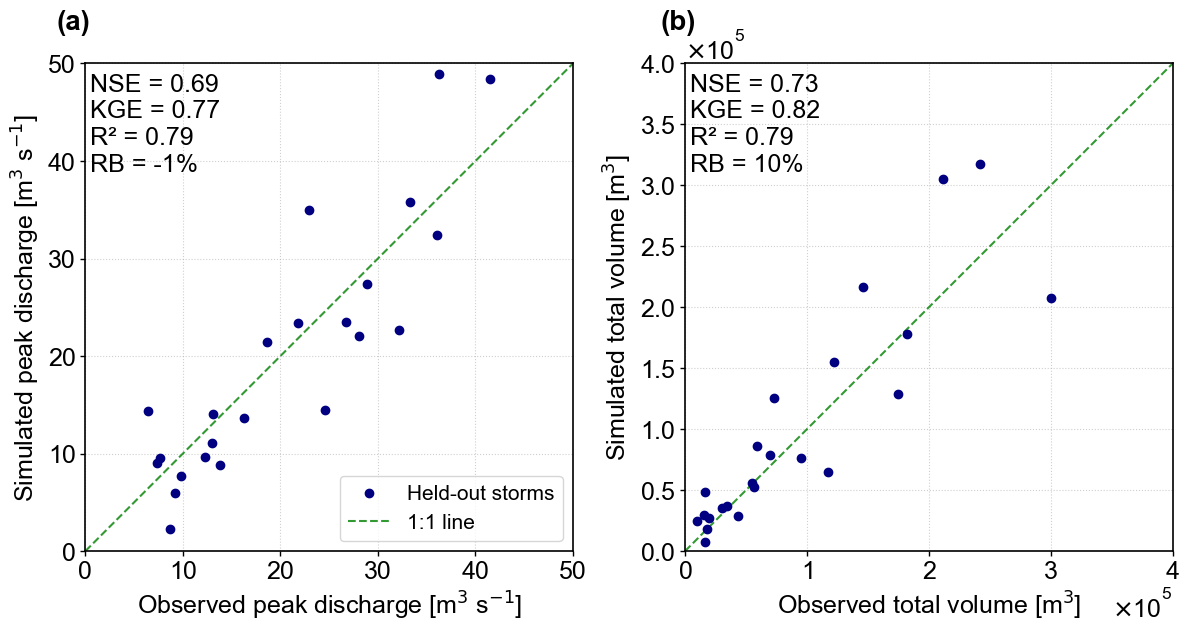

Saved -> outputs\metrics\loocv_validation_scatter.png
Held-out storms: 23


In [10]:
# ── Plot 3: Held-out validation scatter (all 23 folds) ───────────────────────
_all_folds_path = RESULTS_DIR / f'all_folds_{winning_set_name}.pkl'
if not _all_folds_path.exists():
    raise FileNotFoundError(
        f'Fold results not found: {_all_folds_path}\nRun the LOOCV cells above first.'
    )
with open(_all_folds_path, 'rb') as _f:
    _fold_results = pickle.load(_f)

fig3 = plot_loocv_validation_scatter(
    fold_results = _fold_results,
    save_path    = str(METRICS_DIR / 'loocv_validation_scatter.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "loocv_validation_scatter.png"}')
print(f'Held-out storms: {len(_fold_results)}')